# 🏆 Padel Tournament Clustering
### Clustering des tournois par prize money & performance
---
**Project:** Padel Analytics BI Platform (FIP)  
**Objective:** Classifier les tournois en clusters homogènes pour aider les sponsors et organisateurs à comprendre la hiérarchie des compétitions  
**Model type:** Clustering non supervisé — KMeans & GMM  
**Target:** Cluster de tournoi basé sur prize money et performance

| Cluster | Type | Prize Range | Catégorie |
|---------|------|-------------|-----------|
| 0 | 🏆 P1 Medium | ~472K USD | P1 |
| 1 | 👑 Very High Major | ~1.03M USD | Major |
| 2 | ⭐ P2 High | ~252K USD | P2 |
| 3 | 🎾 P1 Standard | ~474K USD | P1 |
| 4 | 🔥 High Finals | ~498K USD | Finals |
| 5 | 📌 P2 Standard | ~261K USD | P2 |
| 6 | 💎 Very High Major Pro | ~1.03M USD | Major |
| 7 | 🏅 High Standard | ~540K USD | High |

## Step 0 — Environment Setup

In [1]:
import subprocess, sys

required = ['scikit-learn', 'pandas', 'numpy', 'matplotlib',
            'seaborn', 'psycopg2-binary', 'sqlalchemy', 'joblib', 'plotly']

for pkg in required:
    try:
        __import__(pkg.replace('-', '_').split('==')[0])
        print(f'✅  {pkg} already installed')
    except ImportError:
        print(f'📦  Installing {pkg}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
        print(f'✅  {pkg} installed')

📦  Installing scikit-learn...
✅  scikit-learn installed
✅  pandas already installed
✅  numpy already installed
✅  matplotlib already installed
✅  seaborn already installed
📦  Installing psycopg2-binary...
✅  psycopg2-binary installed
✅  sqlalchemy already installed
✅  joblib already installed
✅  plotly already installed


## Step 1 — Imports & Configuration

In [3]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA

from sqlalchemy import create_engine
import joblib

# ── Display settings ──────────────────────────────────────────────────────────
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

# ── Plot style ────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'axes.titleweight': 'bold'})

# ── Random seed ───────────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)

print('✅  All libraries imported successfully.')

✅  All libraries imported successfully.


## Step 2 — Configuration

In [5]:
# ── Database ──────────────────────────────────────────────────────────────────
DB_USER     = "postgres"
DB_PASSWORD = "0000"
DB_HOST     = "localhost"
DB_PORT     = "5432"
DB_NAME     = "PIPADEL"
SCHEMA      = "padel"
TABLE_NAME  = "Dim_Tournament"

# ── Round mapping ─────────────────────────────────────────────────────────────
ROUND_MAP = {
    "Winner": 6, "Final": 5, "Semifinals": 4, "Quarterfinals": 3,
    "Round of 16": 2, "Round of 32": 1, "Round of 64": 0,
}

print('✅  Configuration loaded.')

✅  Configuration loaded.


## Step 3 — Data Loading (PostgreSQL)

In [7]:
def load_tournament_data():
    """Load tournament data from PostgreSQL."""
    print('📊  Connecting to PostgreSQL...')
    engine = create_engine(
        f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
    )
    tourn = pd.read_sql(f'SELECT * FROM {SCHEMA}."{TABLE_NAME}"', engine)

    # Clean column names
    tourn.columns = [c.strip().lower().replace(" ", "*") for c in tourn.columns]

    # Identify prize money column
    prize_col = next((c for c in ['prizepoll', 'prizedol', 'prize_pool', 'prize_money']
                      if c in tourn.columns), None)
    if prize_col is None:
        raise ValueError(f"No prize money column found. Available: {list(tourn.columns)}")

    tourn.rename(columns={prize_col: 'prize_money'}, inplace=True)
    tourn['prize_money'] = pd.to_numeric(tourn['prize_money'], errors='coerce')

    print(f'✅  Loaded {tourn.shape[0]} rows × {tourn.shape[1]} columns')
    return tourn

df_raw = load_tournament_data()
print('\n── First 5 rows ──')
display(df_raw.head())

📊  Connecting to PostgreSQL...
✅  Loaded 1736 rows × 10 columns

── First 5 rows ──


,pk_tournament,player*name,tournament*name,round*reached,matches*played,points*earned,prize_money,categorie,country,matches*won
0,1,Ariana Sanchez,Dubai Premier Padel P1,Winner,6,1000,470000.0000,P1,UAE,6
1,2,Paula Josemaria,Dubai Premier Padel P1,Winner,6,1000,470000.0000,P1,UAE,6
2,3,Gemma Triay,Dubai Premier Padel P1,Final,6,600,470000.0000,P1,UAE,5
3,4,Delfina Brea,Dubai Premier Padel P1,Final,6,600,470000.0000,P1,UAE,5
4,5,Bea Gonzalez,Dubai Premier Padel P1,Semifinals,5,360,470000.0000,P1,UAE,4


## Step 4 — Data Understanding
> **Added:** shape, dtypes, missing values, prize money distribution, category breakdown — gives a full picture of the raw data before any transformation.

In [9]:
print('── Shape ──')
print(f'Rows: {df_raw.shape[0]:,}   Columns: {df_raw.shape[1]}')

print('\n── Column types ──')
print(df_raw.dtypes)

print('\n── Missing values ──')
missing = df_raw.isnull().sum()
missing = missing[missing > 0]
print(missing if len(missing) > 0 else 'No missing values ✅')

print('\n── Basic statistics ──')
display(df_raw.describe(include='all'))

── Shape ──
Rows: 1,736   Columns: 10

── Column types ──
pk_tournament        int64
player*name         object
tournament*name     object
round*reached       object
matches*played       int64
points*earned        int64
prize_money        float64
categorie           object
country             object
matches*won          int64
dtype: object

── Missing values ──
No missing values ✅

── Basic statistics ──


,pk_tournament,player*name,tournament*name,round*reached,matches*played,points*earned,prize_money,categorie,country,matches*won
count,1736.0000,1736,1736,1736,1736.0000,1736.0000,1736.0000,1736,1736,1736.0000
unique,NaN,309,21,7,NaN,NaN,NaN,4,11,NaN
top,NaN,Veronica Virseda,Madrid P1,Round of 64,NaN,NaN,NaN,P1,Spain,NaN
freq,NaN,22,192,444,NaN,NaN,NaN,842,461,NaN
mean,868.5000,NaN,NaN,NaN,2.6544,201.4124,542020.7304,NaN,NaN,1.7028
std,501.2844,NaN,NaN,NaN,1.5715,315.3153,257059.8837,NaN,NaN,1.6700
min,1.0000,NaN,NaN,NaN,1.0000,20.0000,235000.0000,NaN,NaN,0.0000
25%,434.7500,NaN,NaN,NaN,1.0000,22.0000,470000.0000,NaN,NaN,0.0000
50%,868.5000,NaN,NaN,NaN,3.0000,90.0000,474500.0000,NaN,NaN,2.0000
75%,1302.2500,NaN,NaN,NaN,4.0000,180.0000,525000.0000,NaN,NaN,3.0000


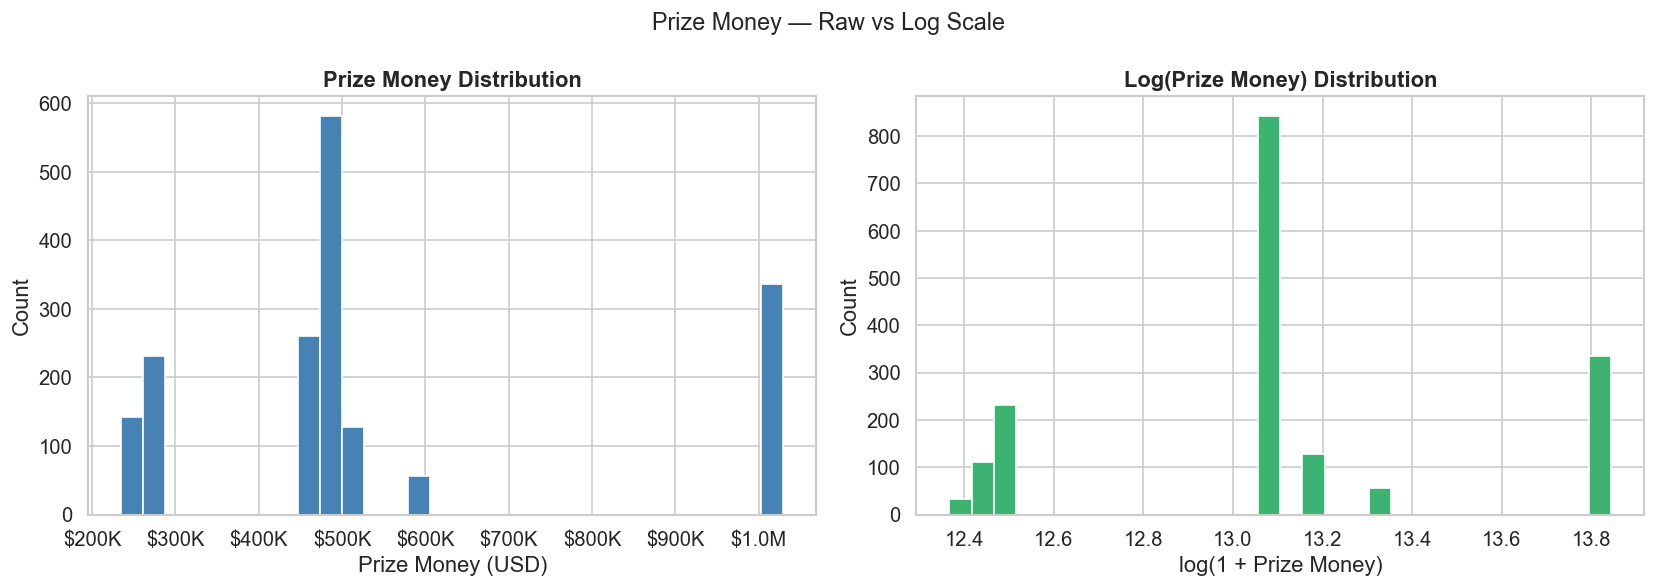

In [11]:
# ── Prize money distribution ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_raw['prize_money'].dropna(), bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Prize Money Distribution')
axes[0].set_xlabel('Prize Money (USD)')
axes[0].set_ylabel('Count')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M' if x >= 1e6 else f'${x/1e3:.0f}K'))

axes[1].hist(np.log1p(df_raw['prize_money'].dropna()), bins=30, color='mediumseagreen', edgecolor='white')
axes[1].set_title('Log(Prize Money) Distribution')
axes[1].set_xlabel('log(1 + Prize Money)')
axes[1].set_ylabel('Count')

plt.suptitle('Prize Money — Raw vs Log Scale', fontsize=14)
plt.tight_layout()
plt.show()

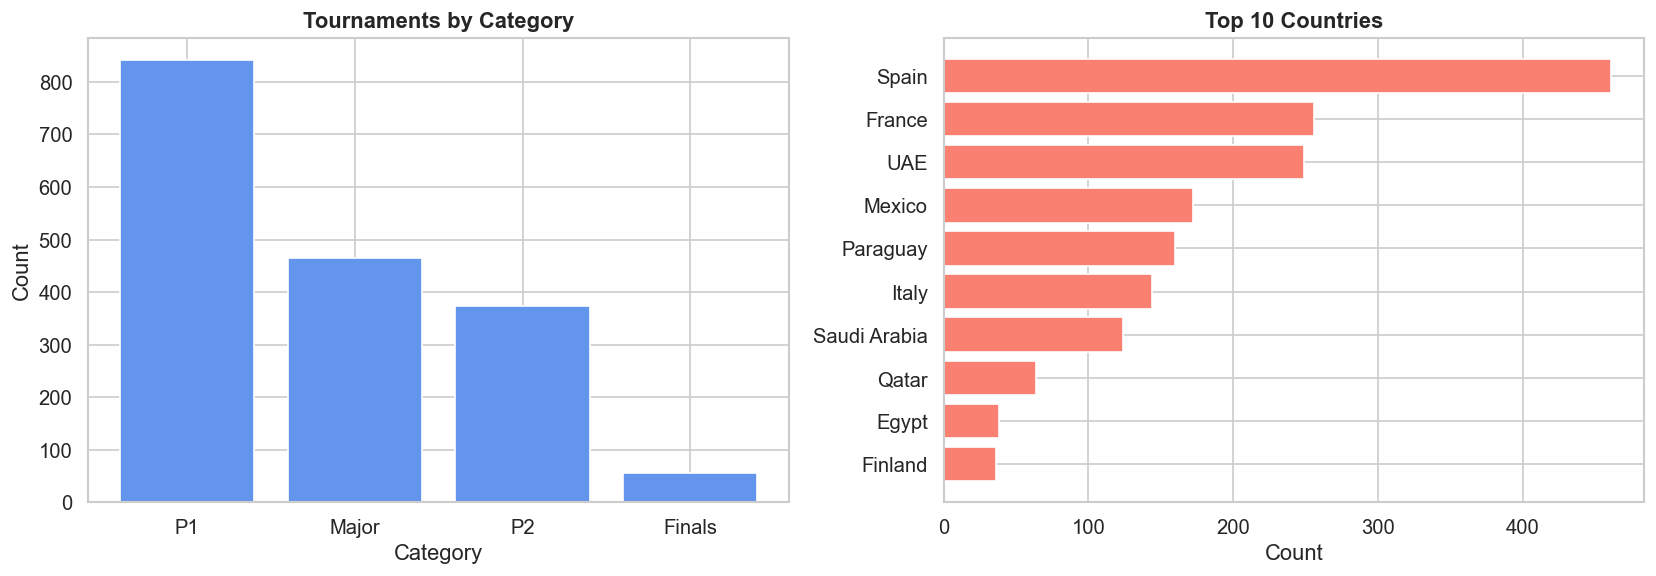


── Prize money by category ──


,count,mean,std,min,25%,50%,75%,max
categorie,,,,,,,,
Finals,56.0000,600000.0000,0.0000,600000.0000,600000.0000,600000.0000,600000.0000,600000.0000
Major,464.0000,890369.5862,225754.4056,525000.0000,525000.0000,1029558.0000,1029558.0000,1029558.0000
P1,842.0000,473105.1069,2082.4126,470000.0000,470000.0000,474500.0000,474500.0000,474500.0000
P2,374.0000,256315.5080,8523.3114,235000.0000,250000.0000,262250.0000,262250.0000,262250.0000


In [23]:
# ── Category & country breakdown ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if 'categorie' in df_raw.columns:
    cat_counts = df_raw['categorie'].value_counts()
    axes[0].bar(cat_counts.index, cat_counts.values, color='cornflowerblue', edgecolor='white')
    axes[0].set_title('Tournaments by Category')
    axes[0].set_xlabel('Category')
    axes[0].set_ylabel('Count')

if 'country' in df_raw.columns:
    top_countries = df_raw['country'].value_counts().head(10)
    axes[1].barh(top_countries.index[::-1], top_countries.values[::-1], color='salmon', edgecolor='white')
    axes[1].set_title('Top 10 Countries')
    axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()

print('\n── Prize money by category ──')
if 'categorie' in df_raw.columns:
    display(df_raw.groupby('categorie')['prize_money'].describe())

## Step 5 — Feature Engineering

In [30]:
def build_tournament_features(tourn):
    """Build features for clustering tournaments by prize money."""
    df = tourn.copy()

    df['prize_log'] = np.log1p(df['prize_money'])

    if 'pk_tournament' not in df.columns:
        df['pk_tournament'] = df.index.astype(str)

    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'], errors='coerce')
        df['year']  = df['date'].dt.year
        df['month'] = df['date'].dt.month

    if 'round*reached' in df.columns:
        df['round_reached_num'] = df['round*reached'].map(ROUND_MAP).fillna(-1).astype(int)
    elif 'round_reached' in df.columns:
        df['round_reached_num'] = df['round_reached'].map(ROUND_MAP).fillna(-1).astype(int)

    tournament_col = next((c for c in ['tournament*name', 'tournament_name'] if c in df.columns), None)
    country_col    = next((c for c in ['country'] if c in df.columns), None)
    category_col   = next((c for c in ['categorie', 'category'] if c in df.columns), None)

    agg_dict = {
        'prize_money': 'first',
        'prize_log':   'first',
        'round_reached_num': ['mean', 'max', 'count'],
    }
    if tournament_col: agg_dict[tournament_col] = 'first'
    if country_col:    agg_dict[country_col]    = lambda x: x.mode()[0] if len(x) > 0 else 'Unknown'
    if category_col:   agg_dict[category_col]   = lambda x: x.mode()[0] if len(x) > 0 else 'Unknown'

    agg = df.groupby('pk_tournament', dropna=False).agg(agg_dict).reset_index()

    # Flatten column names
    agg.columns = ['_'.join(filter(None, map(str, col))).strip('_') if isinstance(col, tuple) else col
                   for col in agg.columns]

    # Rename for clarity
    rename = {
       'prize_money_first': 'prize_money',   # ✅ THIS IS MISSING
    'prize_log_first': 'prize_log',       # (optional but clean)
    'round_reached_num_mean': 'avg_round',
    'round_reached_num_max':  'max_round',
    'round_reached_num_count':'matches_count',
    }
    if tournament_col: rename[f'{tournament_col}_first'] = 'tournament'
    if country_col:    rename[f'{country_col}_<lambda>'] = 'main_country'
    if category_col:   rename[f'{category_col}_<lambda>'] = 'main_category'

    for old, new in rename.items():
        if old in agg.columns:
            agg.rename(columns={old: new}, inplace=True)

    if 'tournament' not in agg.columns and tournament_col:
        matching = [c for c in agg.columns if 'tournament' in c.lower() and c != 'pk_tournament']
        if matching: agg.rename(columns={matching[0]: 'tournament'}, inplace=True)
    if 'main_country' not in agg.columns and country_col:
        matching = [c for c in agg.columns if 'country' in c.lower()]
        if matching: agg.rename(columns={matching[0]: 'main_country'}, inplace=True)
    if 'main_category' not in agg.columns and category_col:
        matching = [c for c in agg.columns if 'categor' in c.lower()]
        if matching: agg.rename(columns={matching[0]: 'main_category'}, inplace=True)

    agg['prize_category'] = pd.cut(
        agg['prize_money'],
        bins=[0, 25000, 100000, 500000, 1000000, float('inf')],
        labels=['Very Low', 'Low', 'Medium', 'High', 'Very High']
    )
    agg['log_prize_per_match'] = agg['prize_log'] / (agg['matches_count'] + 1)
    agg = agg.dropna(subset=['prize_money'])
    agg = agg[agg['prize_money'] > 0]

    print(f'✅  Tournaments retained for clustering: {len(agg)}')
    print('\nPrize category distribution:')
    print(agg['prize_category'].value_counts().sort_index())
    print(f'\nPrize money stats:')
    print(f'  Min    : ${agg["prize_money"].min():,.0f}')
    print(f'  Max    : ${agg["prize_money"].max():,.0f}')
    print(f'  Mean   : ${agg["prize_money"].mean():,.0f}')
    print(f'  Median : ${agg["prize_money"].median():,.0f}')
    return agg

feat_df = build_tournament_features(df_raw)
print('\n── Feature table (first 5 rows) ──')
display(feat_df.head())

✅  Tournaments retained for clustering: 1736

Prize category distribution:
prize_category
Very Low        0
Low             0
Medium       1216
High          184
Very High     336
Name: count, dtype: int64

Prize money stats:
  Min    : $235,000
  Max    : $1,029,558
  Mean   : $542,021
  Median : $474,500

── Feature table (first 5 rows) ──


,pk_tournament,prize_money,prize_log,avg_round,max_round,matches_count,tournament,main_country,main_category,prize_category,log_prize_per_match
0,1,470000.0000,13.0605,6.0000,6,1,Dubai Premier Padel P1,UAE,P1,Medium,6.5302
1,2,470000.0000,13.0605,6.0000,6,1,Dubai Premier Padel P1,UAE,P1,Medium,6.5302
2,3,470000.0000,13.0605,5.0000,5,1,Dubai Premier Padel P1,UAE,P1,Medium,6.5302
3,4,470000.0000,13.0605,5.0000,5,1,Dubai Premier Padel P1,UAE,P1,Medium,6.5302
4,5,470000.0000,13.0605,4.0000,4,1,Dubai Premier Padel P1,UAE,P1,Medium,6.5302


## Step 6 — Preprocessing for Clustering

In [32]:
def preprocess_for_clustering(feat_df):
    """Scale and encode features for clustering."""
    df = feat_df.copy()

    numeric_cols = [c for c in ['prize_log', 'avg_round', 'max_round',
                                 'matches_count', 'log_prize_per_match'] if c in df.columns]
    cat_cols     = [c for c in ['main_category'] if c in df.columns]

    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna(subset=numeric_cols, thresh=len(numeric_cols) - 2)

    X = df[numeric_cols + cat_cols].copy()

    pre = ColumnTransformer(
        transformers=[
            ('num', Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler',  StandardScaler())
            ]), numeric_cols),
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
        ],
        remainder='drop',
    )
    Xp = pre.fit_transform(X)

    print(f'✅  Preprocessing done. Shape for clustering: {Xp.shape}')
    print(f'   Numeric features : {numeric_cols}')
    print(f'   Categorical features : {cat_cols}')
    return X, Xp, pre, numeric_cols, cat_cols, df

X_raw, Xp, pre, numeric_cols, cat_cols, df_clean = preprocess_for_clustering(feat_df)

✅  Preprocessing done. Shape for clustering: (1736, 9)
   Numeric features : ['prize_log', 'avg_round', 'max_round', 'matches_count', 'log_prize_per_match']
   Categorical features : ['main_category']


## Step 7 — Exploratory Data Analysis (EDA)
> **Added:** correlation heatmap and feature boxplots — helps understand relationships between features before clustering.

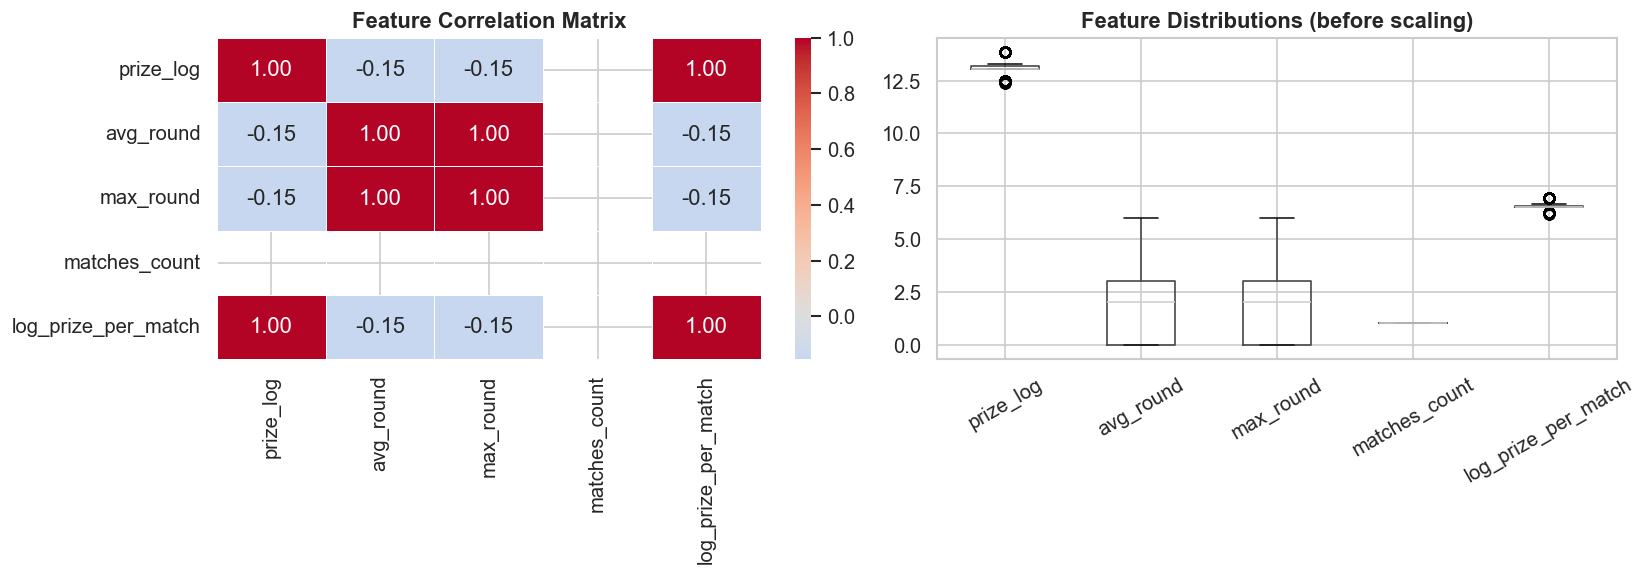

In [34]:
# ── Correlation heatmap ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

corr = X_raw[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=axes[0])
axes[0].set_title('Feature Correlation Matrix')

# ── Feature boxplots ──────────────────────────────────────────────────────────
X_raw[numeric_cols].boxplot(ax=axes[1])
axes[1].set_title('Feature Distributions (before scaling)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

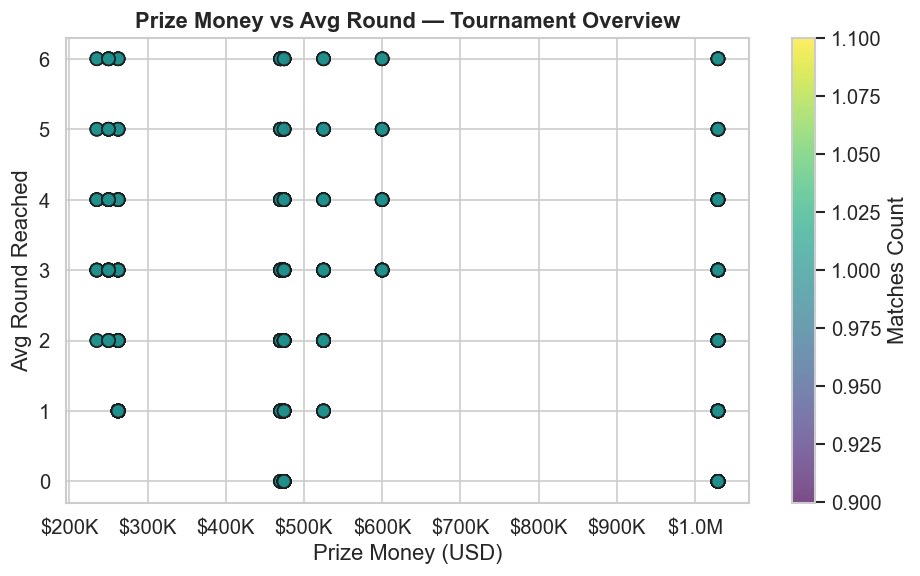

In [36]:
# ── Prize money vs avg_round scatter ─────────────────────────────────────────
plt.figure(figsize=(8, 5))
sc = plt.scatter(feat_df['prize_money'], feat_df['avg_round'],
                 c=feat_df['matches_count'], cmap='viridis', alpha=0.7, edgecolors='k', s=60)
plt.colorbar(sc, label='Matches Count')
plt.xlabel('Prize Money (USD)')
plt.ylabel('Avg Round Reached')
plt.title('Prize Money vs Avg Round — Tournament Overview')
plt.xaxis = plt.gca().xaxis
plt.gca().xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M' if x >= 1e6 else f'${x/1e3:.0f}K')
)
plt.tight_layout()
plt.show()

## Step 8 — Model Training (KMeans & GMM)

In [38]:
def eval_clustering(Xp, labels):
    """Evaluate clustering quality."""
    n_clusters = len(set(labels))
    if n_clusters < 2:
        return {'silhouette': np.nan, 'davies_bouldin': np.nan, 'n_clusters': n_clusters}
    X_dense = Xp if isinstance(Xp, np.ndarray) else Xp.toarray()
    return {
        'silhouette':     float(silhouette_score(X_dense, labels)),
        'davies_bouldin': float(davies_bouldin_score(X_dense, labels)),
        'n_clusters':     n_clusters,
    }

def run_kmeans_grid(Xp, k_min=2, k_max=10, random_state=42):
    """Test different k values for KMeans."""
    rows, inertias = [], []
    for k in range(k_min, k_max + 1):
        km = KMeans(n_clusters=k, n_init=30, random_state=random_state)
        labels = km.fit_predict(Xp)
        m = eval_clustering(Xp, labels)
        rows.append({'model': 'KMeans', 'k': k, **m, 'inertia': float(km.inertia_)})
        inertias.append((k, float(km.inertia_)))
    return pd.DataFrame(rows), pd.DataFrame(inertias, columns=['k', 'inertia'])

def run_gmm_grid(Xp, k_min=2, k_max=10, random_state=42):
    """Test different k values for GMM."""
    rows = []
    X_dense = Xp if isinstance(Xp, np.ndarray) else Xp.toarray()
    for k in range(k_min, k_max + 1):
        gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=random_state)
        gmm.fit(X_dense)
        labels = gmm.predict(X_dense)
        m = eval_clustering(X_dense, labels)
        rows.append({'model': 'GMM', 'k': k, **m,
                     'bic': float(gmm.bic(X_dense)), 'aic': float(gmm.aic(X_dense))})
    return pd.DataFrame(rows)

print('🔄  Running KMeans grid search (k=2..8)...')
kmeans_scores, elbow_df = run_kmeans_grid(Xp, 2, 8)
print('✅  KMeans done.')
print('\nScores KMeans:')
display(kmeans_scores.sort_values('silhouette', ascending=False))

🔄  Running KMeans grid search (k=2..8)...
✅  KMeans done.

Scores KMeans:


,model,k,silhouette,davies_bouldin,n_clusters,inertia
6,KMeans,8,0.6448,0.6843,8,734.6667
5,KMeans,7,0.6098,0.6780,7,889.1815
4,KMeans,6,0.5940,0.7435,6,1216.1886
3,KMeans,5,0.5478,0.7989,5,1637.7532
2,KMeans,4,0.5388,0.7586,4,2104.5508
1,KMeans,3,0.4447,0.9631,3,3335.6129
0,KMeans,2,0.3593,1.2916,2,5244.1762


In [40]:
print('🔄  Running GMM grid search (k=2..8)...')
gmm_scores = run_gmm_grid(Xp, 2, 8)
print('✅  GMM done.')
print('\nScores GMM:')
display(gmm_scores.sort_values('silhouette', ascending=False))

🔄  Running GMM grid search (k=2..8)...
✅  GMM done.

Scores GMM:


,model,k,silhouette,davies_bouldin,n_clusters,bic,aic
4,GMM,6,0.4539,0.9324,6,-144905.9907,-146702.1132
1,GMM,3,0.4390,1.1261,3,-126987.7141,-127883.0457
0,GMM,2,0.4266,0.9119,2,-91575.2077,-92170.2756
5,GMM,7,0.4112,0.9885,7,-149709.5119,-151805.8980
6,GMM,8,0.3950,0.9650,8,-149245.1398,-151641.7896
3,GMM,5,0.3793,1.0401,5,-142798.7911,-144294.6500
2,GMM,4,0.3055,1.6956,4,-136556.2439,-137751.8391


## Step 9 — Model Evaluation & Selection
> **Added:** side-by-side Silhouette + Davies-Bouldin bar chart comparing all k values for both models, plus elbow curve for KMeans — makes picking the best model visual and objective.

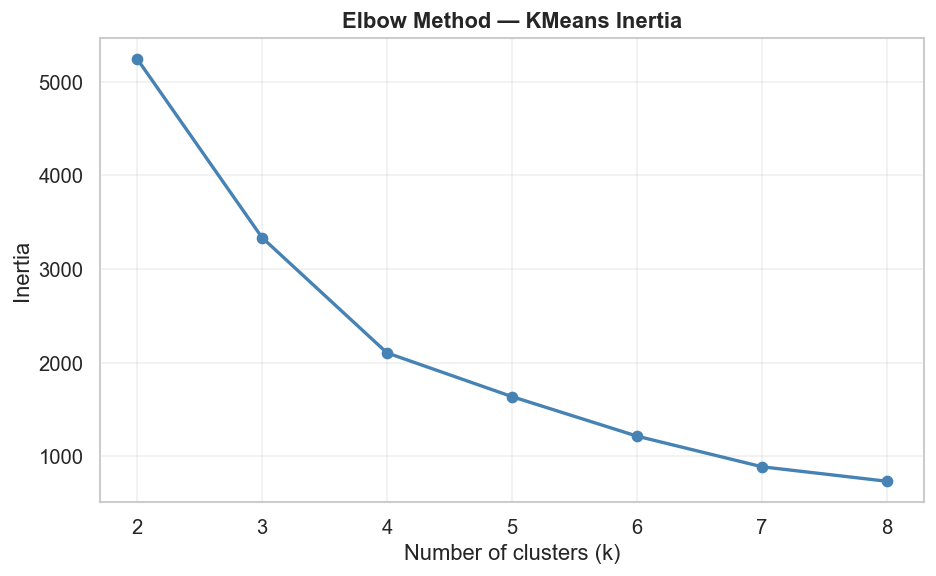

In [42]:
# ── Elbow curve ───────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 5))
plt.plot(elbow_df['k'], elbow_df['inertia'], marker='o', linewidth=2, color='steelblue')
plt.title('Elbow Method — KMeans Inertia')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

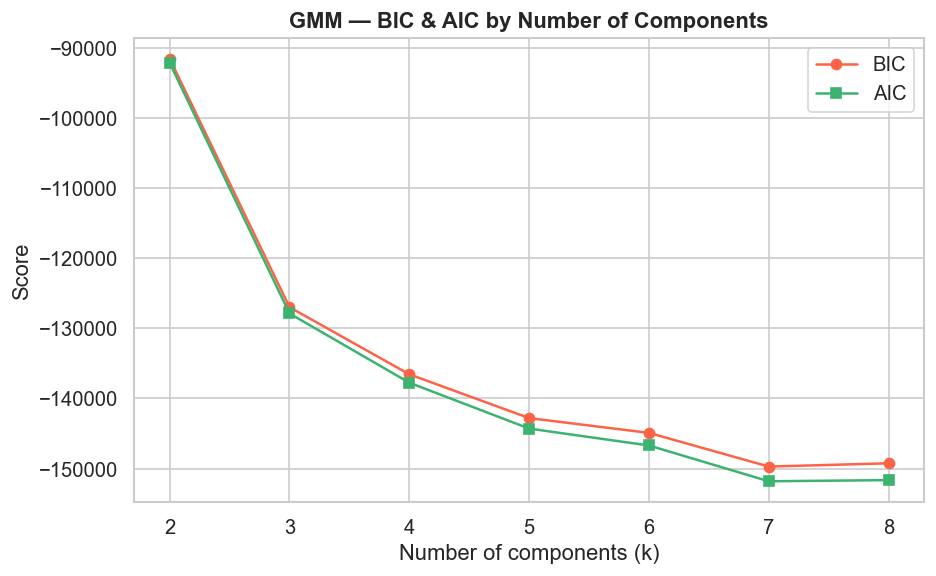

In [44]:
# ── BIC / AIC for GMM ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(gmm_scores['k'], gmm_scores['bic'], marker='o', label='BIC', color='tomato')
ax.plot(gmm_scores['k'], gmm_scores['aic'], marker='s', label='AIC', color='mediumseagreen')
ax.set_title('GMM — BIC & AIC by Number of Components')
ax.set_xlabel('Number of components (k)')
ax.set_ylabel('Score')
ax.legend()
plt.tight_layout()
plt.show()

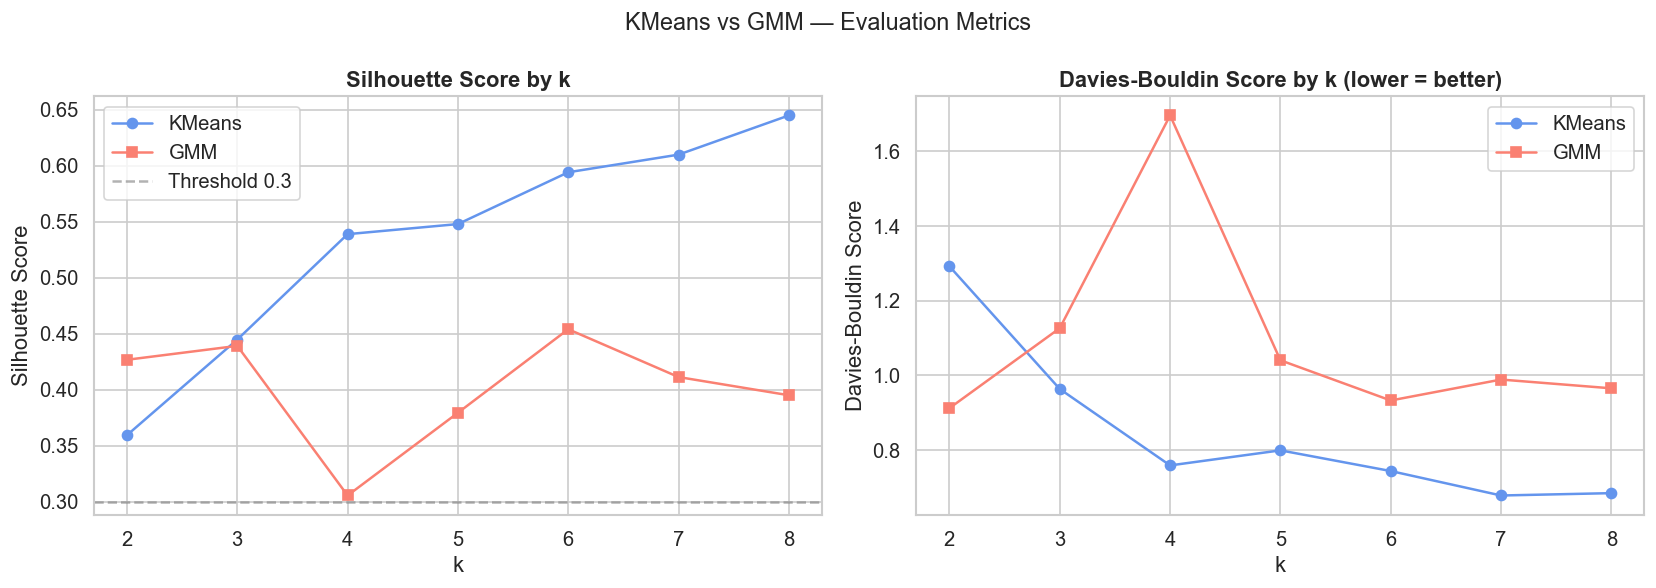

In [46]:
# ── Silhouette comparison — KMeans vs GMM ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(kmeans_scores['k'], kmeans_scores['silhouette'],
             marker='o', color='cornflowerblue', label='KMeans')
axes[0].plot(gmm_scores['k'], gmm_scores['silhouette'],
             marker='s', color='salmon', label='GMM')
axes[0].set_title('Silhouette Score by k')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Silhouette Score')
axes[0].axhline(0.3, color='gray', linestyle='--', alpha=0.6, label='Threshold 0.3')
axes[0].legend()

axes[1].plot(kmeans_scores['k'], kmeans_scores['davies_bouldin'],
             marker='o', color='cornflowerblue', label='KMeans')
axes[1].plot(gmm_scores['k'], gmm_scores['davies_bouldin'],
             marker='s', color='salmon', label='GMM')
axes[1].set_title('Davies-Bouldin Score by k (lower = better)')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Davies-Bouldin Score')
axes[1].legend()

plt.suptitle('KMeans vs GMM — Evaluation Metrics', fontsize=14)
plt.tight_layout()
plt.show()

In [48]:
# ── Select best k for each model and compare ─────────────────────────────────
best_k_km  = int(kmeans_scores.sort_values('silhouette', ascending=False).iloc[0]['k'])
best_k_gmm = int(gmm_scores.sort_values('silhouette', ascending=False).iloc[0]['k'])

km  = KMeans(n_clusters=best_k_km, n_init=30, random_state=SEED)
labels_km = km.fit_predict(Xp)
kmeans_metrics = eval_clustering(Xp, labels_km)
kmeans_metrics['model'] = f'KMeans (k={best_k_km})'

X_dense = Xp if isinstance(Xp, np.ndarray) else Xp.toarray()
gmm = GaussianMixture(n_components=best_k_gmm, covariance_type='full', random_state=SEED)
gmm.fit(X_dense)
labels_gmm = gmm.predict(X_dense)
gmm_metrics = eval_clustering(X_dense, labels_gmm)
gmm_metrics['model'] = f'GMM (k={best_k_gmm})'

comparison = pd.DataFrame([kmeans_metrics, gmm_metrics])
print('\n' + '='*50)
print('FINAL MODEL COMPARISON')
print('='*50)
display(comparison[['model', 'n_clusters', 'silhouette', 'davies_bouldin']])

if kmeans_metrics['silhouette'] >= gmm_metrics['silhouette']:
    best_model_name = f'KMeans (k={best_k_km})'
    final_labels    = labels_km
    final_model     = km
    print(f'\n✅  Best model: KMeans (k={best_k_km})  — Silhouette = {kmeans_metrics["silhouette"]:.4f}')
else:
    best_model_name = f'GMM (k={best_k_gmm})'
    final_labels    = labels_gmm
    final_model     = gmm
    print(f'\n✅  Best model: GMM (k={best_k_gmm})  — Silhouette = {gmm_metrics["silhouette"]:.4f}')


FINAL MODEL COMPARISON


,model,n_clusters,silhouette,davies_bouldin
0,KMeans (k=8),8,0.6448,0.6843
1,GMM (k=6),6,0.4539,0.9324



✅  Best model: KMeans (k=8)  — Silhouette = 0.6448


## Step 10 — Cluster Visualisation (PCA)

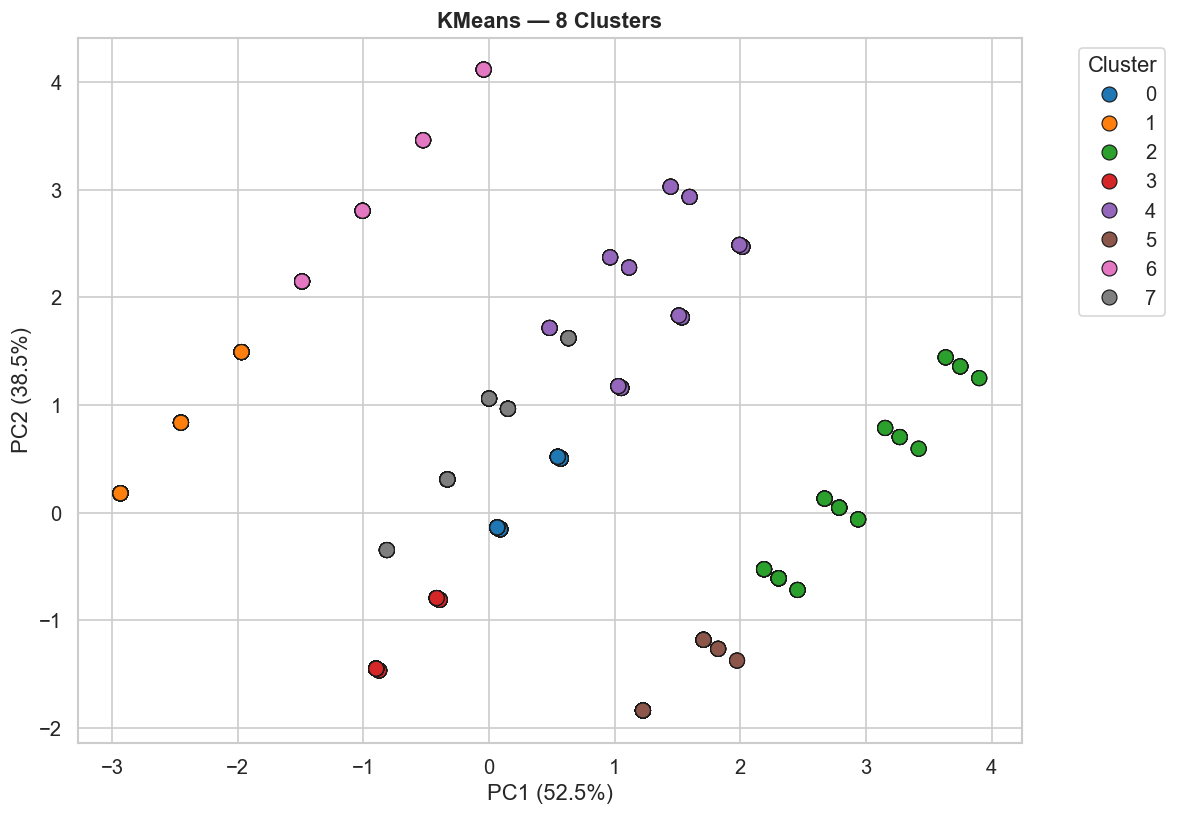

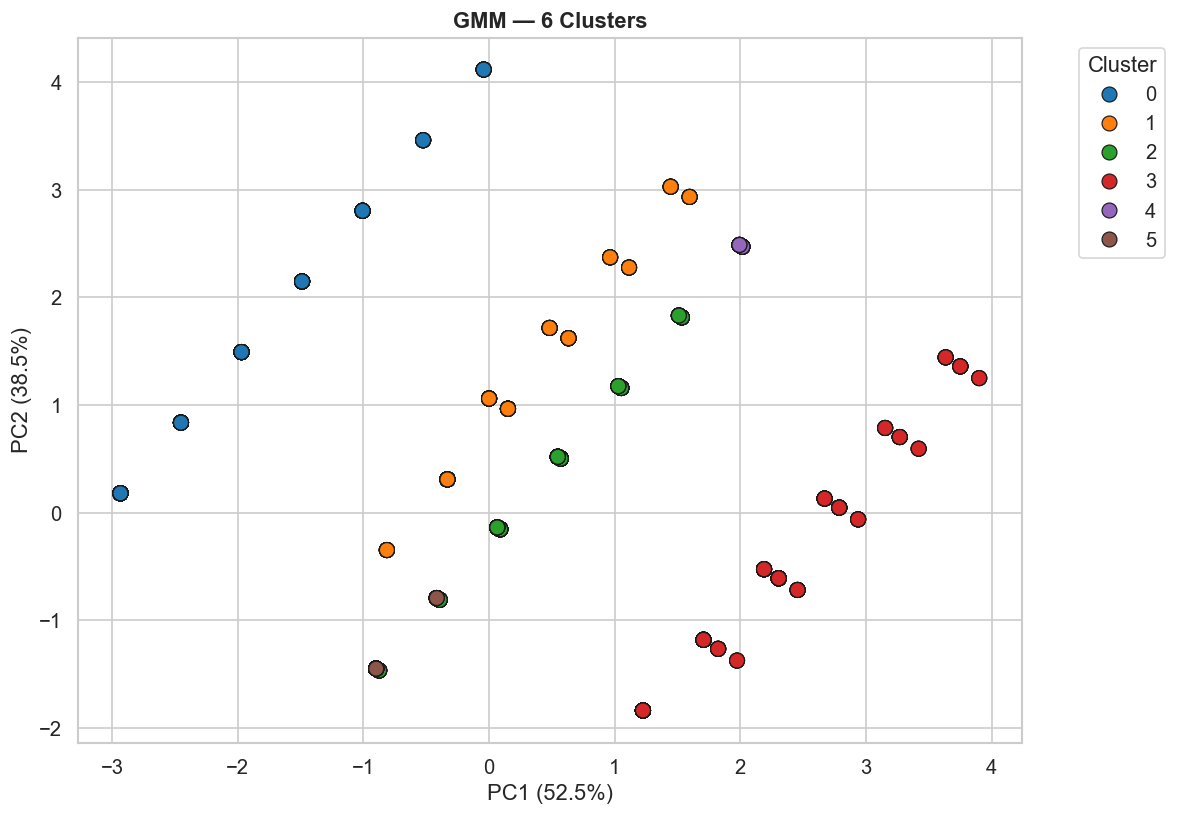

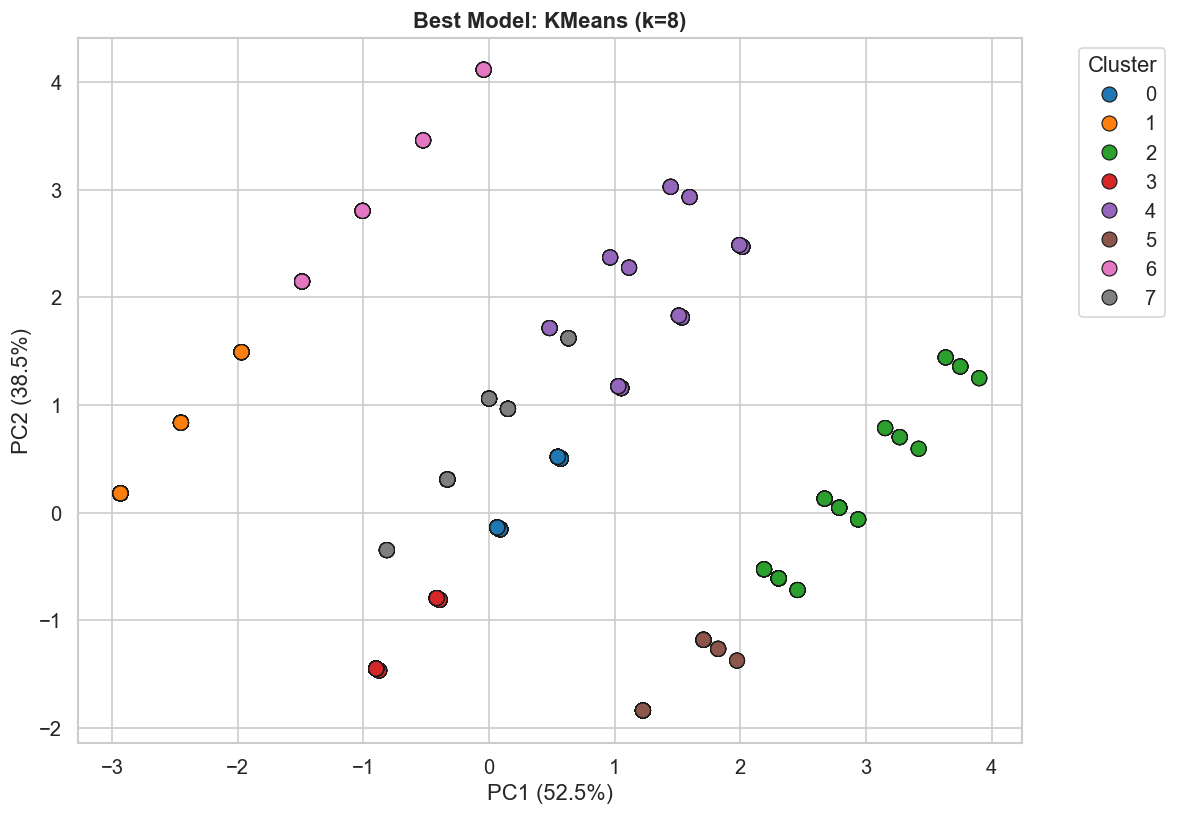

In [50]:
def plot_pca_scatter(Xp, labels, title):
    """PCA 2D visualisation of clusters."""
    X_dense = Xp if isinstance(Xp, np.ndarray) else Xp.toarray()
    pca = PCA(n_components=2, random_state=SEED)
    Z   = pca.fit_transform(X_dense)
    plt.figure(figsize=(10, 7))
    sns.scatterplot(x=Z[:, 0], y=Z[:, 1], hue=labels,
                    palette='tab10', s=80, edgecolor='k')
    plt.title(title)
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
    plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

plot_pca_scatter(Xp, labels_km,  f'KMeans — {best_k_km} Clusters')
plot_pca_scatter(Xp, labels_gmm, f'GMM — {best_k_gmm} Clusters')
plot_pca_scatter(Xp, final_labels, f'Best Model: {best_model_name}')

## Step 11 — Cluster Profiling & Interpretation


=== Cluster Summary ===


,prize_log,avg_round,max_round,matches_count,log_prize_per_match,avg_prize_money,count
cluster,,,,,,,
0,13.0700,2.4600,2.4600,1.0000,6.5300,472382.0000,272
1,13.8400,0.7300,0.7300,1.0000,6.9200,1029558.0000,240
2,12.4400,3.9000,3.9000,1.0000,6.2200,251694.0000,186
3,13.0700,0.2800,0.2800,1.0000,6.5300,473798.0000,442
4,13.1100,4.8400,4.8400,1.0000,6.5600,497953.0000,172
5,12.4700,1.2800,1.2800,1.0000,6.2400,260888.0000,188
6,13.8400,3.8800,3.8800,1.0000,6.9200,1029558.0000,96
7,13.2000,2.5400,2.5400,1.0000,6.6000,540000.0000,140


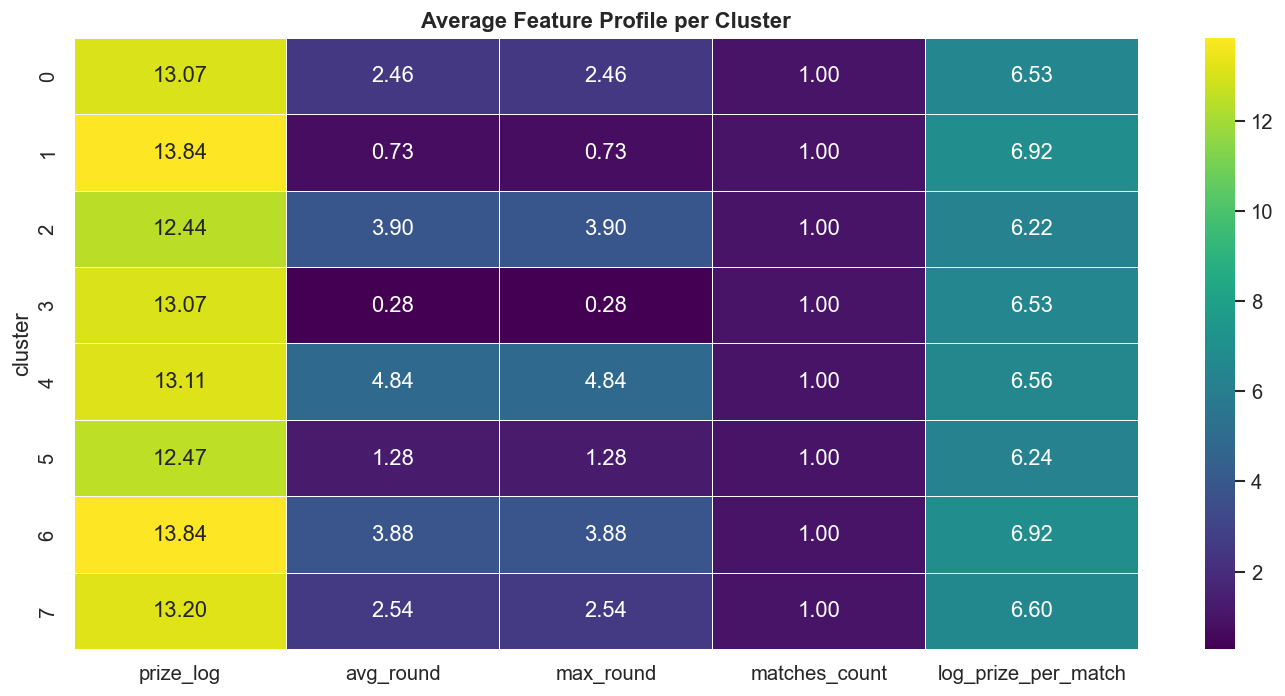


=== Top 5 Tournaments per Cluster (by prize money) ===

--- Cluster 0 (272 tournaments) ---
      tournament  prize_money prize_category main_category main_country  matches_count  avg_round
Riyadh Season P1  474500.0000         Medium            P1 Saudi Arabia              1     2.0000
       Madrid P1  474500.0000         Medium            P1        Spain              1     3.0000
       Malaga P1  474500.0000         Medium            P1        Spain              1     2.0000
       Malaga P1  474500.0000         Medium            P1        Spain              1     2.0000
       Malaga P1  474500.0000         Medium            P1        Spain              1     2.0000

--- Cluster 1 (240 tournaments) ---
 tournament  prize_money prize_category main_category main_country  matches_count  avg_round
Italy Major 1029558.0000      Very High         Major        Italy              1     2.0000
Italy Major 1029558.0000      Very High         Major        Italy              1     2.0000
Par

In [52]:
def cluster_profiling(feat_df, labels, numeric_cols):
    """Profile each cluster."""
    prof = feat_df.copy()
    prof['cluster'] = labels

    summary = prof.groupby('cluster')[numeric_cols].mean().round(2)
    summary['avg_prize_money'] = prof.groupby('cluster')['prize_money'].mean().round(0)
    summary['count']           = prof.groupby('cluster').size()

    print('\n=== Cluster Summary ===')
    display(summary)

    plt.figure(figsize=(12, 6))
    sns.heatmap(summary[numeric_cols], annot=True, cmap='viridis',
                fmt='.2f', linewidths=0.5)
    plt.title('Average Feature Profile per Cluster')
    plt.tight_layout()
    plt.show()

    print('\n=== Top 5 Tournaments per Cluster (by prize money) ===')
    for c in sorted(prof['cluster'].unique()):
        sub  = prof[prof['cluster'] == c].sort_values('prize_money', ascending=False).head(5)
        cols = [col for col in ['tournament', 'prize_money', 'prize_category',
                                'main_category', 'main_country', 'matches_count', 'avg_round']
                if col in sub.columns]
        print(f'\n--- Cluster {c} ({len(prof[prof["cluster"]==c])} tournaments) ---')
        print(sub[cols].to_string(index=False))

cluster_profiling(df_clean, final_labels, numeric_cols)

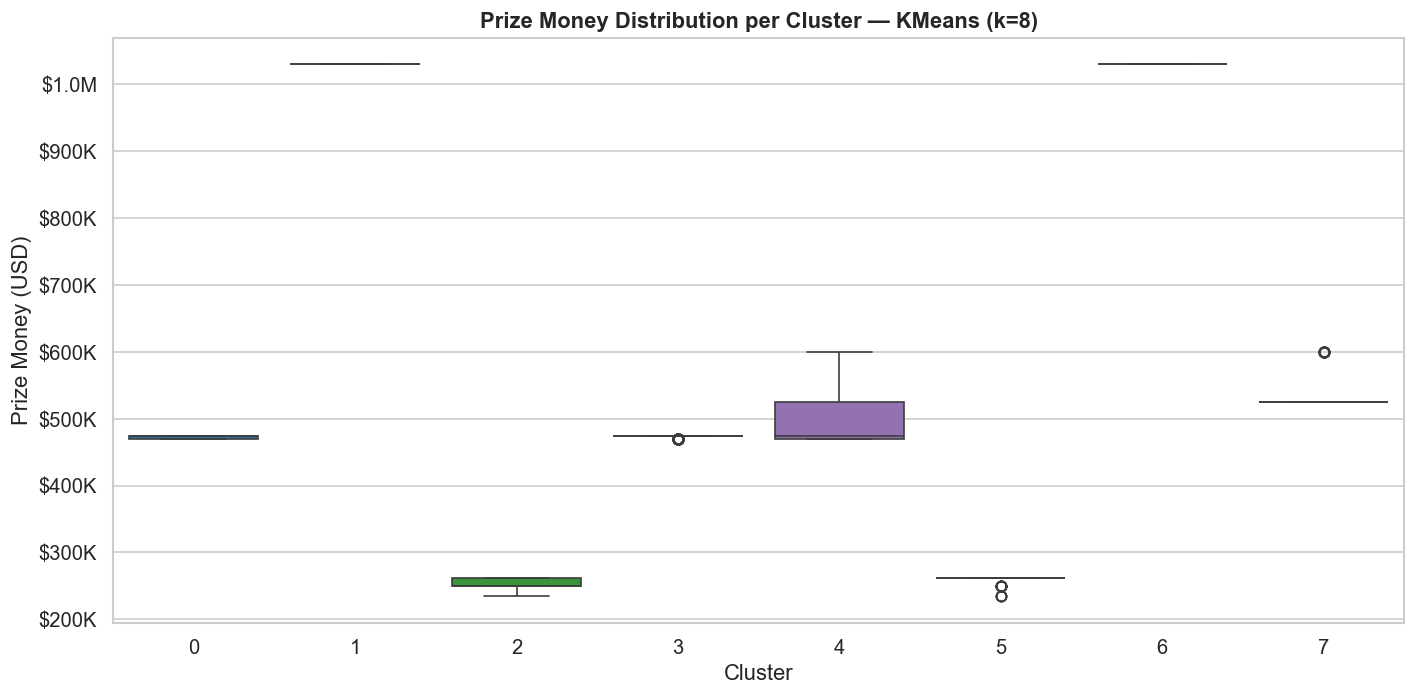

In [54]:
# ── Prize money distribution per cluster ─────────────────────────────────────
prof = df_clean.copy()
prof['cluster'] = final_labels

plt.figure(figsize=(12, 6))
sns.boxplot(data=prof, x='cluster', y='prize_money', palette='tab10')
plt.title(f'Prize Money Distribution per Cluster — {best_model_name}')
plt.xlabel('Cluster')
plt.ylabel('Prize Money (USD)')
plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M' if x >= 1e6 else f'${x/1e3:.0f}K')
)
plt.tight_layout()
plt.show()

## Step 12 — Export Results & Save Models

In [56]:
# ── Save cluster assignments ──────────────────────────────────────────────────
out = df_clean[['pk_tournament'] +
               [c for c in ['tournament', 'prize_money', 'prize_category',
                             'main_category', 'main_country'] if c in df_clean.columns]].copy()
out['cluster']    = final_labels
out['model_used'] = best_model_name

output_path = r"c:\\Users\\Lenovo\\Desktop\\DW\\tournaments_clusters.csv"
out.to_csv(output_path, index=False, sep=';')
print(f'✅  Cluster file saved: {output_path}')

print(f'\nTotal tournaments clustered : {len(out)}')
print(f'Number of clusters          : {len(out["cluster"].unique())}')
print(f'Model used                  : {best_model_name}')
print('\nCluster distribution:')
print(out['cluster'].value_counts().sort_index())

OSError: Cannot save file into a non-existent directory: 'c:\Users\Lenovo\Desktop\DW'

In [ ]:
# ── Save model and preprocessor ──────────────────────────────────────────────
joblib.dump(final_model, 'kmeans_model.pkl')
joblib.dump(pre,         'preprocessor.pkl')
print('✅  kmeans_model.pkl saved')
print('✅  preprocessor.pkl saved')